# SPARTAN vs IMPROVE: EC mass on filter vs FABS

Presentation notebook for Anne's requested story: compare SPARTAN HIPS/FABS behavior against the full IMPROVE network in **filter loading space**, not concentration space.

The core question is whether the Addis/ETAD behavior is an Addis-only HIPS problem, a broader SPARTAN problem, or a site-specific relationship that also appears at Delhi/Beijing/JPL.


## 0. Data status and caveats

**Getting the data together first.** The clean final SPARTAN dataset is still expected from Mona/Anne/Alex. The current local data are enough to build the presentation logic, but they should be treated as a working first pass:

- EC is not available from the public SPARTAN website, so the website is not a sufficient source.
- Public SPARTAN FABS units have a history of inconsistent scaling, so this notebook does not scrape or trust the website for FABS.
- The intended trusted sources are Mona's compiled SPARTAN OC, EC, FTIR, and HIPS data, plus Alex/Naveed for SPARTAN FABS.
- This notebook currently uses the local `unified_filter_dataset.pkl` SPARTAN filter table and the local cleaned IMPROVE pull.

**Why EC mass on filter?** Concentrations are not directly comparable across the networks because sampling volumes and filter handling differ. IMPROVE EC mass is back-calculated as concentration times sampled volume; SPARTAN uses measured mass loading where available, with a concentration-times-volume fallback.


## 1. Setup


In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path('/Users/ahmadjalil/github/aethmodular')
FTIR_DIR = REPO / 'research' / 'ftir_hips_chem'
OUT_DIR = REPO / 'research' / 'improve_hips_offset' / 'output' / 'anne_spartan_improve_ec_mass_fabs'
FIG_DIR = OUT_DIR / 'figures'
TAB_DIR = OUT_DIR / 'tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(FTIR_DIR / 'scripts'))
from outliers import apply_exclusion_flags, apply_threshold_flags
from plotting import apply_default_style

apply_default_style()
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

SPARTAN_FILTER_PATH = FTIR_DIR / 'Filter Data' / 'unified_filter_dataset.pkl'
IMPROVE_CLEAN_PATH = FTIR_DIR / 'output' / 'improve_high_fabs_comparison' / 'improve_valid_cleaned.csv'

SITE_CODE_TO_NAME = {
    'CHTS': 'Beijing',
    'INDH': 'Delhi',
    'USPA': 'JPL/Pasadena',
    'ETAD': 'Addis/Ethiopia',
}
SITE_ORDER = ['Addis/Ethiopia', 'Delhi', 'JPL/Pasadena', 'Beijing']
SITE_COLORS = {
    'Addis/Ethiopia': '#D7191C',  # red
    'Delhi': '#2C7BB6',           # blue
    'JPL/Pasadena': '#1A9641',    # green
    'Beijing': '#F28E2B',         # orange
}

print(f'Writing outputs to {OUT_DIR.relative_to(REPO)}')


Writing outputs to research/improve_hips_offset/output/anne_spartan_improve_ec_mass_fabs


## 2. Load and harmonize the two networks


In [2]:
def regression_stats(df, x_col='EC_mass_ug', y_col='FABS_Mm1'):
    d = df[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()
    d = d[(d[x_col] > 0) & (d[y_col] > 0)]
    if len(d) < 3:
        return {'n': len(d), 'slope': np.nan, 'intercept': np.nan, 'r2': np.nan, 'origin_slope': np.nan}
    x = d[x_col].to_numpy(float)
    y = d[y_col].to_numpy(float)
    slope, intercept = np.polyfit(x, y, 1)
    pred = slope * x + intercept
    ss_res = np.sum((y - pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    origin_slope = np.sum(x * y) / np.sum(x ** 2)
    return {
        'n': int(len(d)),
        'slope': slope,
        'intercept': intercept,
        'r2': 1 - ss_res / ss_tot if ss_tot > 0 else np.nan,
        'origin_slope': origin_slope,
    }


def percentile_bounds(df, x_col='EC_mass_ug', y_col='FABS_Mm1'):
    q = df[[x_col, y_col]].quantile([0.05, 0.50, 0.95])
    return {
        'x05': q.loc[0.05, x_col], 'x50': q.loc[0.50, x_col], 'x95': q.loc[0.95, x_col],
        'y05': q.loc[0.05, y_col], 'y50': q.loc[0.50, y_col], 'y95': q.loc[0.95, y_col],
    }


def load_improve():
    usecols = [
        'Dataset', 'SiteCode', 'Date', 'ECf_Val', 'fAbs_Val', 'volume_m3', 'EC_loading_ug',
        'SampDur_Val', 'FlowRate_Val', 'SiteName', 'State', 'Latitude', 'Longitude',
    ]
    imp = pd.read_csv(IMPROVE_CLEAN_PATH, usecols=lambda c: c in set(usecols), parse_dates=['Date'], low_memory=False)
    imp['EC_mass_ug'] = imp['EC_loading_ug']
    missing_mass = imp['EC_mass_ug'].isna() & imp['ECf_Val'].notna() & imp['volume_m3'].notna()
    imp.loc[missing_mass, 'EC_mass_ug'] = imp.loc[missing_mass, 'ECf_Val'] * imp.loc[missing_mass, 'volume_m3']
    imp = imp.rename(columns={'fAbs_Val': 'FABS_Mm1', 'Date': 'date'})
    imp['network'] = 'IMPROVE'
    imp['site_group'] = 'IMPROVE'
    keep = imp[(imp['EC_mass_ug'] > 0) & (imp['FABS_Mm1'] > 0)].copy()
    return keep


def load_spartan():
    long = pd.read_pickle(SPARTAN_FILTER_PATH)
    long['SampleDate'] = pd.to_datetime(long['SampleDate'], errors='coerce')
    long['site_group'] = long['Site'].map(SITE_CODE_TO_NAME)
    params = ['EC_ftir', 'HIPS_Fabs', 'HIPS_T1', 'HIPS_R1', 'HIPS_t', 'HIPS_r']
    wide = (
        long[long['Parameter'].isin(params)]
        .pivot_table(
            index=['Site', 'site_group', 'FilterId', 'SampleDate', 'FilterType', 'LotId', 'DepositArea_cm2', 'Volume_m3'],
            columns='Parameter',
            values='Concentration',
            aggfunc='first',
        )
        .reset_index()
    )
    wide.columns.name = None

    ec_mass = (
        long[long['Parameter'].eq('EC_ftir')][['FilterId', 'MassLoading_ug']]
        .drop_duplicates('FilterId')
        .rename(columns={'MassLoading_ug': 'EC_mass_ug'})
    )
    wide = wide.merge(ec_mass, on='FilterId', how='left')
    fallback = wide['EC_mass_ug'].isna() & wide['EC_ftir'].notna() & wide['Volume_m3'].notna()
    wide.loc[fallback, 'EC_mass_ug'] = wide.loc[fallback, 'EC_ftir'] * wide.loc[fallback, 'Volume_m3']
    wide['FABS_Mm1'] = wide['HIPS_Fabs']
    wide['date'] = wide['SampleDate']
    wide['network'] = 'SPARTAN'
    wide['EC_surface_ug_cm2'] = wide['EC_mass_ug'] / wide['DepositArea_cm2']

    frames = []
    for site_label in SITE_ORDER:
        site_code = {v: k for k, v in SITE_CODE_TO_NAME.items()}[site_label]
        site_for_exclusions = {'Addis/Ethiopia': 'Addis_Ababa', 'JPL/Pasadena': 'JPL'}.get(site_label, site_label)
        d = wide[(wide['Site'].eq(site_code)) & (wide['FilterType'].eq('PM2.5'))].copy()
        d['aeth_bc'] = pd.NA
        d['filter_ec'] = d['EC_ftir'] * 1000.0
        d['filter_id'] = d['FilterId']
        d = apply_exclusion_flags(d, site_for_exclusions)
        d = apply_threshold_flags(d, site_for_exclusions)
        clean = d[
            (~d['is_excluded'])
            & (~d['is_outlier'])
            & (d['EC_mass_ug'] > 0)
            & (d['FABS_Mm1'] > 0)
        ].copy()
        frames.append(clean)
    return wide, pd.concat(frames, ignore_index=True)

improve = load_improve()
spartan_all, spartan = load_spartan()

print(f'IMPROVE usable EC mass + FABS rows: {len(improve):,} across {improve.SiteCode.nunique():,} sites')
print(f'IMPROVE date range: {improve.date.min().date()} to {improve.date.max().date()}')
print(f'SPARTAN usable PM2.5 EC mass + FABS rows: {len(spartan):,}')
print(spartan.groupby('site_group').size().reindex(SITE_ORDER))


IMPROVE usable EC mass + FABS rows: 152,029 across 177 sites
IMPROVE date range: 2015-08-01 to 2025-07-30
SPARTAN usable PM2.5 EC mass + FABS rows: 538
site_group
Addis/Ethiopia    190
Delhi              60
JPL/Pasadena      128
Beijing           160
dtype: int64


In [3]:
summary_rows = []
for label, df in [('IMPROVE', improve), *[(site, spartan[spartan['site_group'].eq(site)]) for site in SITE_ORDER]]:
    stats = regression_stats(df)
    bounds = percentile_bounds(df)
    summary_rows.append({'group': label, **stats, **bounds})
summary = pd.DataFrame(summary_rows)

improve_origin = summary.loc[summary['group'].eq('IMPROVE'), 'origin_slope'].iloc[0]
summary['origin_slope_vs_improve'] = summary['origin_slope'] / improve_origin
summary.to_csv(TAB_DIR / 'ec_mass_fabs_fit_and_bounds.csv', index=False)
display(summary.round(3))


,group,n,slope,intercept,r2,origin_slope,x05,x50,x95,y05,y50,y95,origin_slope_vs_improve
0,IMPROVE,152029,0.136,1.213,0.421,0.175,0.449,3.230,16.719,0.180,1.310,5.630,1.000
1,Addis/Ethiopia,190,0.532,29.391,0.687,1.198,16.680,33.504,69.329,34.681,47.132,68.043,6.865
2,Delhi,60,1.301,14.268,0.463,1.803,3.269,17.059,49.398,3.809,38.101,83.076,10.328
3,JPL/Pasadena,128,1.243,0.330,0.543,1.327,1.796,3.503,5.648,1.317,4.682,8.104,7.602
4,Beijing,160,0.851,5.583,0.627,1.239,2.756,8.509,23.744,4.224,12.828,27.612,7.097


## 3. Build-up plot: all IMPROVE plus the four SPARTAN sites

This is the first plot for Warren/Cena: no shading, no complicated screens, just the full IMPROVE cloud in gray and the four SPARTAN sites in color. Dots are intentionally large enough to see in slides.


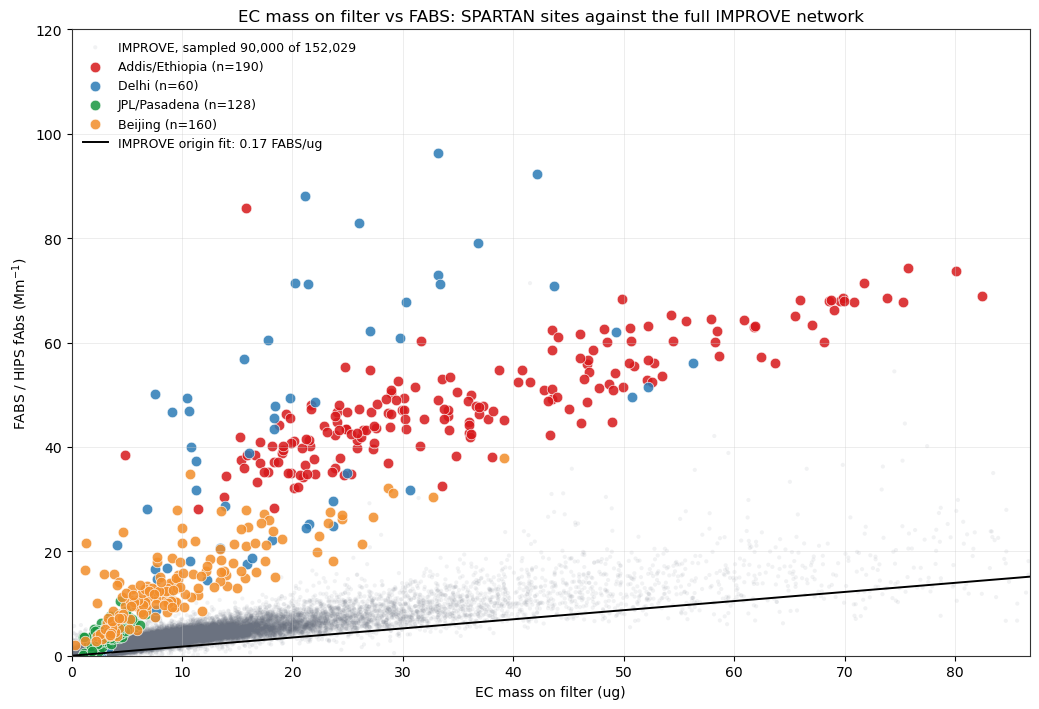

In [4]:
fig, ax = plt.subplots(figsize=(10.5, 7.2))

imp_plot = improve.sample(min(len(improve), 90000), random_state=7)
ax.scatter(
    imp_plot['EC_mass_ug'], imp_plot['FABS_Mm1'],
    s=9, alpha=0.09, color='#6B7280', edgecolor='none', rasterized=True,
    label=f'IMPROVE, sampled {len(imp_plot):,} of {len(improve):,}'
)

for site in SITE_ORDER:
    g = spartan[spartan['site_group'].eq(site)]
    ax.scatter(
        g['EC_mass_ug'], g['FABS_Mm1'],
        s=58, alpha=0.86, color=SITE_COLORS[site], edgecolor='white', linewidth=0.5,
        label=f'{site} (n={len(g)})'
    )

xline = np.linspace(0, max(55, spartan['EC_mass_ug'].quantile(.995) * 1.15), 200)
fit_imp = regression_stats(improve)
ax.plot(xline, fit_imp['origin_slope'] * xline, color='black', lw=1.4, label=f'IMPROVE origin fit: {fit_imp["origin_slope"]:.2f} FABS/ug')

ax.set_xlim(0, max(55, spartan['EC_mass_ug'].quantile(.995) * 1.15))
ax.set_ylim(0, max(120, spartan['FABS_Mm1'].quantile(.995) * 1.10))
ax.set_xlabel('EC mass on filter (ug)')
ax.set_ylabel('FABS / HIPS fAbs (Mm$^{-1}$)')
ax.set_title('EC mass on filter vs FABS: SPARTAN sites against the full IMPROVE network')
ax.legend(frameon=False, loc='upper left', fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig01_all_improve_gray_four_spartan_sites.png', dpi=240, bbox_inches='tight')
plt.show()


## 4. Per-site overlap panels with 5th-95th percentile bands

Each panel shades that SPARTAN site's 5th-95th percentile range on **both axes**. The printed count asks: how many IMPROVE filters are simultaneously inside that site's EC-mass range and FABS range?


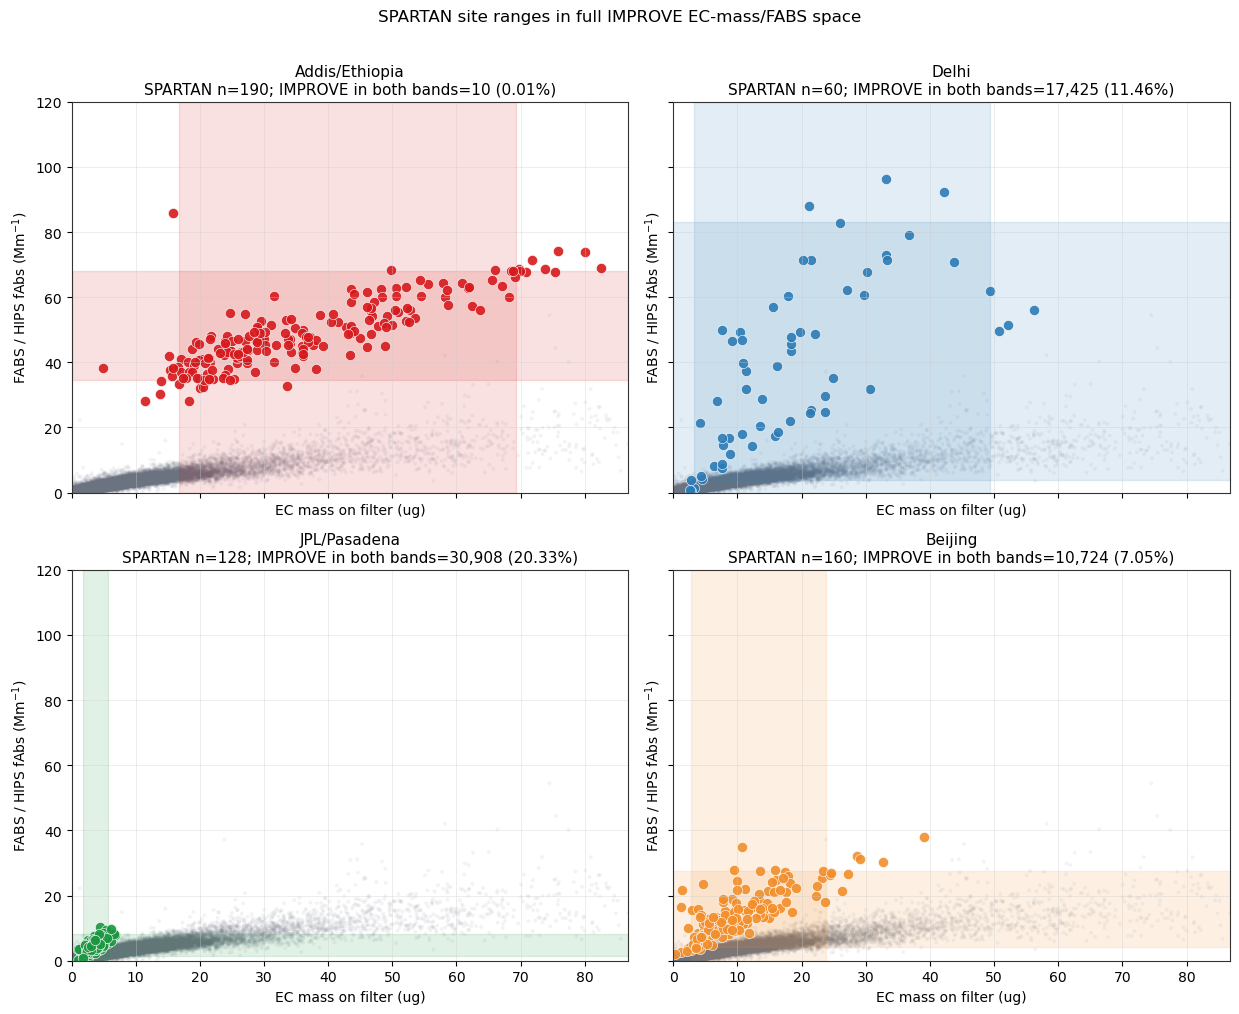

,site,spartan_n,improve_overlap_n,improve_overlap_pct,x05,x50,x95,y05,y50,y95
0,Addis/Ethiopia,190,10,0.007,16.680,33.504,69.329,34.681,47.132,68.043
1,Delhi,60,17425,11.462,3.269,17.059,49.398,3.809,38.101,83.076
2,JPL/Pasadena,128,30908,20.330,1.796,3.503,5.648,1.317,4.682,8.104
3,Beijing,160,10724,7.054,2.756,8.509,23.744,4.224,12.828,27.612


In [5]:
overlap_rows = []
fig, axes = plt.subplots(2, 2, figsize=(12.5, 10), sharex=True, sharey=True)
axes = axes.ravel()

xmax = max(55, spartan['EC_mass_ug'].quantile(.995) * 1.15)
ymax = max(120, spartan['FABS_Mm1'].quantile(.995) * 1.10)
imp_plot = improve.sample(min(len(improve), 70000), random_state=12)

for ax, site in zip(axes, SITE_ORDER):
    g = spartan[spartan['site_group'].eq(site)]
    b = percentile_bounds(g)
    mask_x = improve['EC_mass_ug'].between(b['x05'], b['x95'], inclusive='both')
    mask_y = improve['FABS_Mm1'].between(b['y05'], b['y95'], inclusive='both')
    overlap = improve[mask_x & mask_y]
    overlap_rows.append({
        'site': site,
        'spartan_n': len(g),
        'improve_overlap_n': len(overlap),
        'improve_overlap_pct': 100 * len(overlap) / len(improve),
        **b,
    })

    ax.scatter(imp_plot['EC_mass_ug'], imp_plot['FABS_Mm1'], s=8, alpha=0.08, color='#6B7280', edgecolor='none', rasterized=True)
    ax.axvspan(b['x05'], b['x95'], color=SITE_COLORS[site], alpha=0.13)
    ax.axhspan(b['y05'], b['y95'], color=SITE_COLORS[site], alpha=0.13)
    ax.scatter(g['EC_mass_ug'], g['FABS_Mm1'], s=54, alpha=0.90, color=SITE_COLORS[site], edgecolor='white', linewidth=0.45)

    title = f'{site}\nSPARTAN n={len(g)}; IMPROVE in both bands={len(overlap):,} ({100 * len(overlap) / len(improve):.2f}%)'
    ax.set_title(title, fontsize=11)
    ax.set_xlim(0, xmax)
    ax.set_ylim(0, ymax)
    ax.set_xlabel('EC mass on filter (ug)')
    ax.set_ylabel('FABS / HIPS fAbs (Mm$^{-1}$)')

fig.suptitle('SPARTAN site ranges in full IMPROVE EC-mass/FABS space', y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig02_site_percentile_bands_overlap.png', dpi=240, bbox_inches='tight')
plt.show()

overlap = pd.DataFrame(overlap_rows)
overlap.to_csv(TAB_DIR / 'site_percentile_band_improve_overlap.csv', index=False)
display(overlap.round(3))


## 5. Site-specific fits: does JPL/Pasadena land on the IMPROVE line?

The sanity check is JPL/Pasadena. A US urban SPARTAN site should be much closer to the IMPROVE relationship than Addis if the issue is site- or instrument-specific rather than universal to SPARTAN.


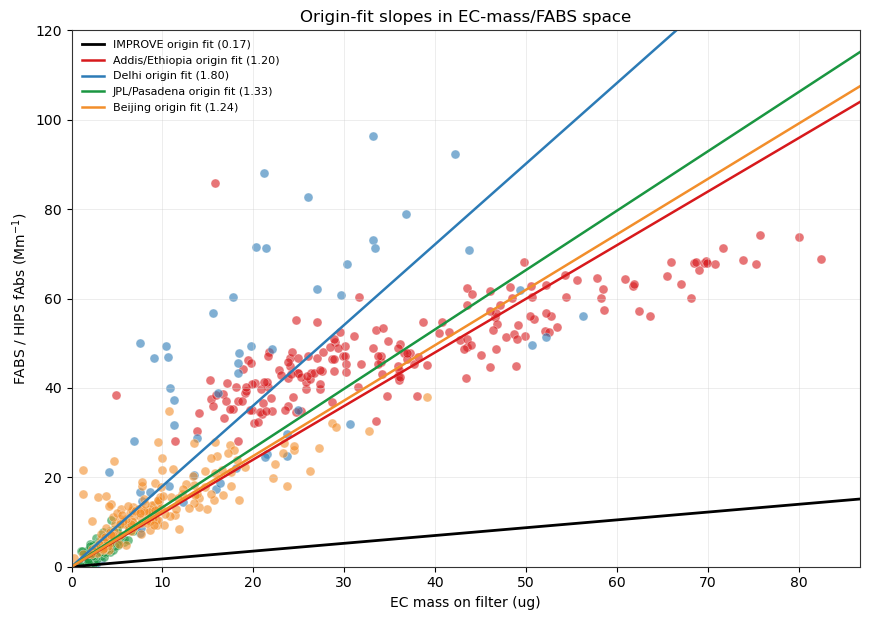

,group,n,slope,intercept,r2,origin_slope,origin_slope_vs_improve
0,IMPROVE,152029,0.136,1.213,0.421,0.175,1.000
1,Addis/Ethiopia,190,0.532,29.391,0.687,1.198,6.865
2,Delhi,60,1.301,14.268,0.463,1.803,10.328
3,JPL/Pasadena,128,1.243,0.330,0.543,1.327,7.602
4,Beijing,160,0.851,5.583,0.627,1.239,7.097


In [6]:
fig, ax = plt.subplots(figsize=(8.8, 6.3))
xline = np.linspace(0, xmax, 200)
fit_imp = regression_stats(improve)
ax.plot(xline, fit_imp['origin_slope'] * xline, color='black', lw=2.0, label=f'IMPROVE origin fit ({fit_imp["origin_slope"]:.2f})')

fit_rows = [{'group': 'IMPROVE', **fit_imp}]
for site in SITE_ORDER:
    g = spartan[spartan['site_group'].eq(site)]
    fit = regression_stats(g)
    fit_rows.append({'group': site, **fit})
    ax.scatter(g['EC_mass_ug'], g['FABS_Mm1'], s=42, alpha=0.60, color=SITE_COLORS[site], edgecolor='white', linewidth=0.35)
    if np.isfinite(fit['origin_slope']):
        ax.plot(xline, fit['origin_slope'] * xline, color=SITE_COLORS[site], lw=1.8, label=f'{site} origin fit ({fit["origin_slope"]:.2f})')

ax.set_xlim(0, xmax)
ax.set_ylim(0, ymax)
ax.set_xlabel('EC mass on filter (ug)')
ax.set_ylabel('FABS / HIPS fAbs (Mm$^{-1}$)')
ax.set_title('Origin-fit slopes in EC-mass/FABS space')
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig03_origin_fit_slope_comparison.png', dpi=240, bbox_inches='tight')
plt.show()

fits = pd.DataFrame(fit_rows)
fits['origin_slope_vs_improve'] = fits['origin_slope'] / fit_imp['origin_slope']
fits.to_csv(TAB_DIR / 'origin_fit_slope_comparison.csv', index=False)
display(fits.round(3))


## 6. White et al. pixelation direction check

**Descriptive slide language.** White et al. describe a pixelation/loading artifact in IMPROVE where heavy deposits can cause **underestimation** of FABS at high loadings. The Ethiopia result we are seeing is the opposite direction: for comparable EC mass on the filter, Addis/Ethiopia sits **above** the IMPROVE relationship, implying apparent FABS overestimation relative to EC mass.

That direction mismatch is the headline. SPARTAN filters may visually show more striking pixelation, but if the White-style artifact predicts lower FABS and Addis shows higher FABS, pixelation alone does not explain the Addis HIPS story.


## 7. SPARTAN-only R/T diagnostic plots

We can show SPARTAN raw-ish R/T fields by site, with field blanks as boxes and samples as circles when those blank rows are present locally. We should **not** put SPARTAN and IMPROVE on the same R/T plot here: the needed raw IMPROVE HIPS R/T calibration fields, blank metadata, filter IDs, lot numbers, and correction details are not available in the local FED-style comparison table in the same way.


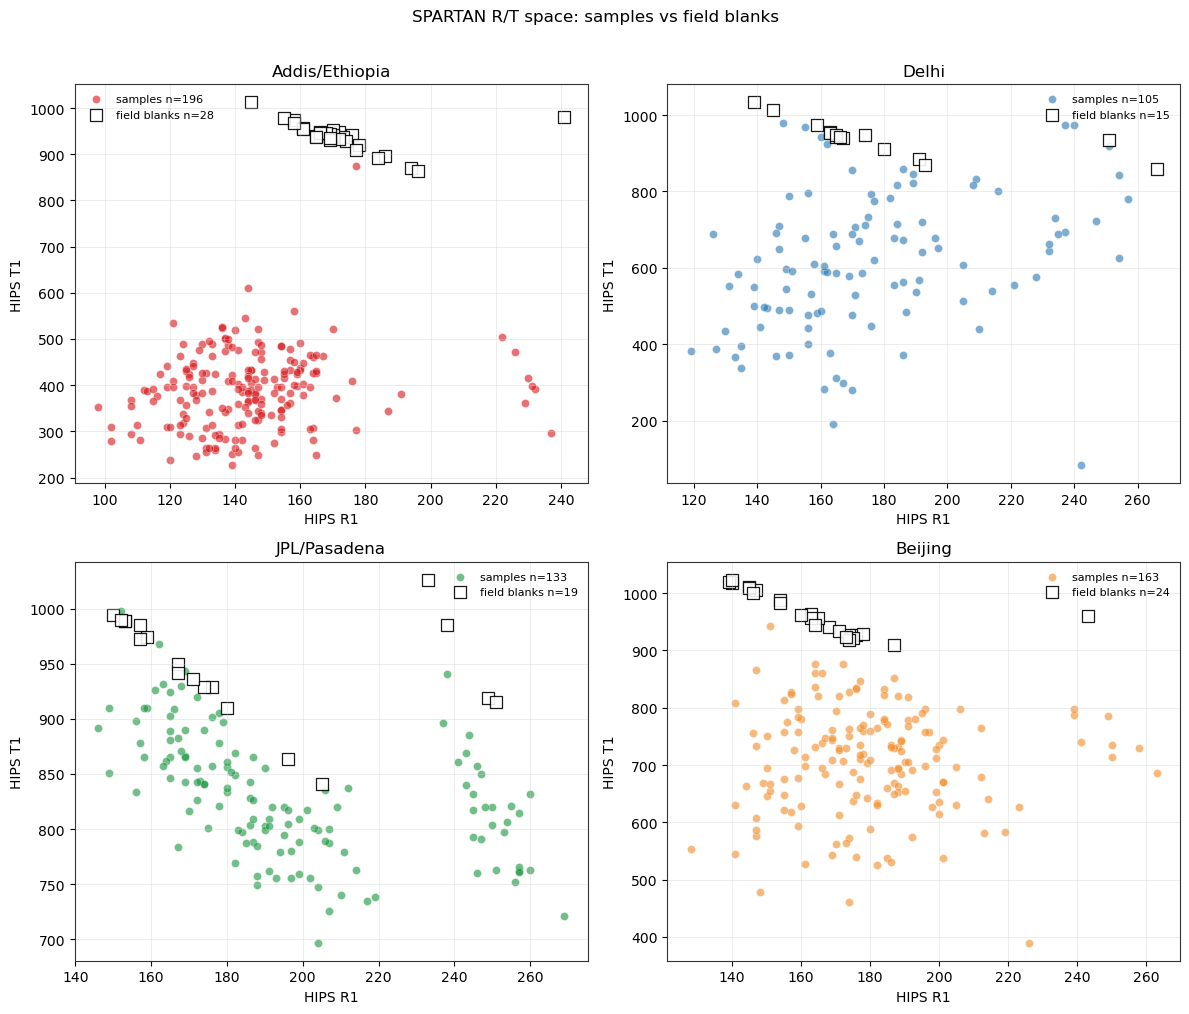

,site_group,LotId,blank_or_sample,n
0,Addis/Ethiopia,248.0,field_blank,5
1,Addis/Ethiopia,248.0,sample,35
2,Addis/Ethiopia,251.0,field_blank,23
3,Addis/Ethiopia,251.0,sample,161
4,Beijing,248.0,field_blank,3
5,Beijing,248.0,sample,20
6,Beijing,251.0,field_blank,21
7,Beijing,251.0,sample,143
8,Delhi,248.0,field_blank,3
9,Delhi,248.0,sample,21


In [7]:
rt_long = pd.read_pickle(SPARTAN_FILTER_PATH)
rt_long['SampleDate'] = pd.to_datetime(rt_long['SampleDate'], errors='coerce')
rt_long['site_group'] = rt_long['Site'].map(SITE_CODE_TO_NAME)
rt_long = rt_long[
    rt_long['site_group'].isin(SITE_ORDER)
    & rt_long['Parameter'].isin(['HIPS_R1', 'HIPS_T1'])
].copy()

rt = (
    rt_long.pivot_table(
        index=['Site', 'site_group', 'FilterId', 'FilterType', 'LotId'],
        columns='Parameter',
        values='Concentration',
        aggfunc='first',
    )
    .reset_index()
)
rt.columns.name = None
rt = rt[rt['HIPS_R1'].notna() & rt['HIPS_T1'].notna()].copy()
rt['is_blank'] = rt['FilterType'].eq('FB')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
for ax, site in zip(axes, SITE_ORDER):
    g = rt[rt['site_group'].eq(site)]
    samples = g[~g['is_blank']]
    blanks = g[g['is_blank']]
    ax.scatter(samples['HIPS_R1'], samples['HIPS_T1'], s=34, alpha=0.62, color=SITE_COLORS[site], edgecolor='white', linewidth=0.35, label=f'samples n={len(samples)}')
    ax.scatter(blanks['HIPS_R1'], blanks['HIPS_T1'], s=76, marker='s', alpha=0.90, color='white', edgecolor='black', linewidth=0.9, label=f'field blanks n={len(blanks)}')
    ax.set_title(site)
    ax.set_xlabel('HIPS R1')
    ax.set_ylabel('HIPS T1')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle('SPARTAN R/T space: samples vs field blanks', y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig04_spartan_rt_samples_blanks_by_site.png', dpi=240, bbox_inches='tight')
plt.show()

rt_counts = (
    rt.assign(blank_or_sample=np.where(rt['is_blank'], 'field_blank', 'sample'))
    .groupby(['site_group', 'LotId', 'blank_or_sample'], dropna=False)
    .size()
    .rename('n')
    .reset_index()
    .sort_values(['site_group', 'LotId', 'blank_or_sample'])
)
rt_counts.to_csv(TAB_DIR / 'spartan_rt_counts_by_site_lot.csv', index=False)
display(rt_counts)


## 8. Presentation takeaways

- Use EC mass on filter as the common x-axis; avoid concentration-vs-concentration framing for the cross-network comparison.
- The all-network plot is the build-up: full IMPROVE in gray, four SPARTAN sites in color, no shading.
- The per-site percentile-band plots quantify how little the networks overlap in the two-dimensional EC-mass/FABS space.
- JPL/Pasadena is the sanity check. If it lands near IMPROVE while Addis does not, the story points away from a universal SPARTAN issue.
- The White et al. pixelation comparison is a direction check: IMPROVE pixelation underestimation vs Addis apparent overestimation.
- R/T plots are useful for Warren, but keep them SPARTAN-only unless the raw IMPROVE HIPS calibration fields and blank/lot metadata arrive.


In [8]:
print('Figures written:')
for path in sorted(FIG_DIR.glob('*.png')):
    print(' ', path.relative_to(REPO))
print('\nTables written:')
for path in sorted(TAB_DIR.glob('*.csv')):
    print(' ', path.relative_to(REPO))


Figures written:
  research/improve_hips_offset/output/anne_spartan_improve_ec_mass_fabs/figures/fig01_all_improve_gray_four_spartan_sites.png
  research/improve_hips_offset/output/anne_spartan_improve_ec_mass_fabs/figures/fig02_site_percentile_bands_overlap.png
  research/improve_hips_offset/output/anne_spartan_improve_ec_mass_fabs/figures/fig03_origin_fit_slope_comparison.png
  research/improve_hips_offset/output/anne_spartan_improve_ec_mass_fabs/figures/fig04_spartan_rt_samples_blanks_by_site.png

Tables written:
  research/improve_hips_offset/output/anne_spartan_improve_ec_mass_fabs/tables/ec_mass_fabs_fit_and_bounds.csv
  research/improve_hips_offset/output/anne_spartan_improve_ec_mass_fabs/tables/origin_fit_slope_comparison.csv
  research/improve_hips_offset/output/anne_spartan_improve_ec_mass_fabs/tables/site_percentile_band_improve_overlap.csv
  research/improve_hips_offset/output/anne_spartan_improve_ec_mass_fabs/tables/spartan_rt_counts_by_site_lot.csv
